# Pseudo-spherical correction

This notebook compares principal-plane radiance computed with a plane-parallel
geometry and with a spherical-shell geometry. The latter activates CDISORT's
pseudo-spherical correction, which replaces the flat-slab airmass `1 / cos(SZA)`
of the direct beam with the Chapman function (the diffuse field remains
plane-parallel).

In [1]:
# Documentation-specific setup, hidden from notebook output

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import seaborn as sns

sns.set_theme(style="ticks")

In [2]:
import eradiate
import matplotlib.pyplot as plt
import numpy as np
from eradiate.experiments import AtmosphereExperiment
from eradiate.units import unit_registry as ureg

import eradiate_disort as ed
from eradiate_disort.util import disort_reshape_pplane

eradiate.set_mode("ckd")

# Experiment parameters
SZA = 85.0
ZENITHS = np.arange(-85.0, 86.0, 1.0)
SPP = 100_000

In [3]:
# Dev-specific setup, hidden from notebook output

from eradiate_disort.testing import TestMode

plt = TestMode.plt()
SPP = TestMode.spp(tutorial=100_000, test=1_000)

In [4]:
# Define the experiment depending on the geometry requested by the user.


def make_exp(geometry, backend="disort"):
    srf = {"type": "delta", "wavelengths": [440.0, 550.0, 660.0]}
    if backend == "disort":
        measure = {
            "type": "disort",
            "construct": "hplane",
            "azimuth": 0.0,
            "zeniths": ZENITHS,
            "srf": srf,
        }
    else:
        measure = {
            "type": "mdistant",
            "construct": "hplane",
            "azimuth": 0.0,
            "zeniths": ZENITHS,
            "srf": srf,
        }
    return AtmosphereExperiment(
        geometry={
            "type": geometry,
            "toa_altitude": 100.0 * ureg.km,
            "zgrid": np.linspace(0, 100, 101) * ureg.km,
        },
        surface={"type": "lambertian", "reflectance": 0.0},
        atmosphere={
            "type": "molecular",
            "has_scattering": True,
            "has_absorption": True,
        },
        illumination={"type": "directional", "zenith": SZA, "azimuth": 0.0},
        measures=measure,
    )


exp_pp = make_exp("plane_parallel")
exp_ss_disort = make_exp("spherical_shell")
exp_ss_mitsuba = make_exp("spherical_shell", backend="mitsuba")

In [5]:
# Run both experiments
results = {}
results["pp"] = disort_reshape_pplane(
    ed.DisortBackend().run(exp_pp).sel(z=1e5, drop=True)
).squeeze()
results["ss_disort"] = disort_reshape_pplane(
    ed.DisortBackend().run(exp_ss_disort).sel(z=1e5, drop=True)
).squeeze()
results["ss_mitsuba"] = (
    eradiate.run(exp_ss_mitsuba, spp=SPP)["radiance"]
    .squeeze()
    .swap_dims({"x_index": "vza"})
)

0/48|          | 00:00, ETA=?

0/48|          | 00:00, ETA=?

0/48|          | 00:00, ETA=?

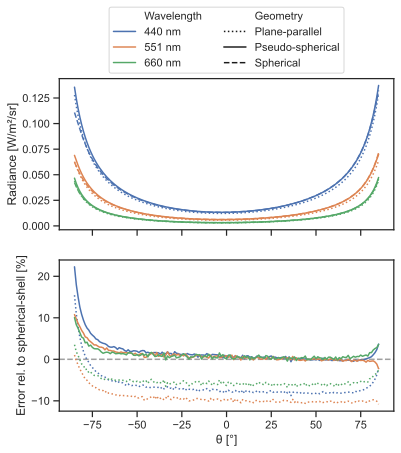

In [6]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = [Patch(visible=False, label="Wavelength")]
ls = {"pp": ":", "ss_disort": "-", "ss_mitsuba": "--"}

fig, axs = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

ax = axs[0]
w = results["pp"]["w"].values

for i_w_, w_ in enumerate(w):
    color = f"C{i_w_}"
    for geometry in ["pp", "ss_disort", "ss_mitsuba"]:
        result = results[geometry]
        x = result["vza"].values
        y = result.sel(w=w_).values
        ax.plot(x, y, c=color, ls=ls[geometry])
    legend_elements.append(Line2D([0], [0], color=color, label=f"{w_:.0f} nm"))

legend_elements.extend(
    [
        Patch(visible=False, label="Geometry"),
        Line2D([0], [0], color="k", ls=ls["pp"], label="Plane-parallel"),
        Line2D([0], [0], color="k", ls=ls["ss_disort"], label="Pseudo-spherical"),
        Line2D([0], [0], color="k", ls=ls["ss_mitsuba"], label="Spherical"),
    ]
)


ax.set_ylabel("Radiance [W/m²/sr]")
ax.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(0.5, 1), ncol=2)

ax = axs[1]

for i_w_, w_ in enumerate(w):
    # w_ = w[0]
    color = f"C{i_w_}"
    ref = results["ss_mitsuba"].sel(w=w_)

    for geometry in ["ss_disort", "pp"]:
        result = results[geometry]
        x = result["vza"].values
        obs = result.sel(w=w_).values
        y = (obs - ref) / ref * 100.0
        ax.plot(x, y, color=color, ls=ls[geometry])

ax.axhline(0.0, ls="--", color="gray", alpha=0.75, zorder=1)
ax.set_xlabel("θ [°]")
ax.set_ylabel("Error rel. to spherical-shell [%]")

plt.show()